# Introduction

The purpose of this project is to examine how demographic, parental, and religious factors influence youth drug use behavior. Understanding the drivers of substance use among youth is crucial for identifying at-risk groups and informing prevention strategies. 

In this analysis, we use a dataset containing survey responses from youths, which includes information on their background characteristics, family orientation, youth experiences and religiosity. Our research will focus on three research questions.To explore these relationships, we apply tree-based machine learning methods, including decision trees, bagging, boosting, and random forest, to capture both simple and complex patterns in the data. The results provide insight into which factors are most strongly associated with youth drug use and how these relationships vary across different modeling approaches.

 ### Research Question
 How do demographics, parental influence, and religiosity predict youth drug and marijuana use behavior, specifically:
1. Whether a youth has ever used any drug (binary classification - Used/Never Used)
2. The frequency of marijuana use in the past month (multi-class classification)?
3. The number of days per year a youth has used marijuana (regression)?


#### Import the required Libraries & Datasets



In [133]:
library(dplyr)
library(ggplot2)
library(tree)

To import the dataset

In [134]:
download.file(
  "https://raw.githubusercontent.com/mendible/5322/main/Homework%201/youth_data.Rdata",
  "youth_data.RData",
  mode = "wb"
)

file.exists("youth_data.RData")

# Load the RData file
load("youth_data.RData")  # contains df



[1] TRUE

### Data Preprocessing


In this section, we transform the dataset by cleaning invalid entries, recoding variables into meaningful categories, and constructing new features that capture key behaviors of interest. These steps—commonly referred to as data preprocessing and feature engineering—allow us to convert the original dataset into a structured form appropriate for classification, regression, and exploratory analysis.

In [135]:
youth_data_df <- df %>%
  mutate(
    # BINARY: ever used any drug (alcohol, marijuana, or tobacco)
    # ALCFLAG, MRJFLAG, TOBFLAG are already clean 0/1 flags in dataset
    if_drug_usage = factor(
      ifelse(ALCFLAG == 1 | MRJFLAG == 1 | TOBFLAG == 1, 1, 0),
      levels = c(0, 1),
      labels = c("Never Used", "Used")
    ),
    
    # MULTI-CLASS: marijuana frequency past month (already coded 1-5)
    # 1=1-2 days, 2=3-5 days, 3=6-19 days, 4=20-30 days, 5=non-user
    MRJ_NUM_DAYS = factor(
      MRJMDAYS,
      levels = c(1, 2, 3, 4, 5),
      labels = c("1-2 days", "3-5 days", "6-19 days", "20-30 days", "Non-user")
    ),
    
    # REGRESSION: days of marijuana use past year (IRMJFY)
    # Range for Marijuana Frequency Past Year (IRMJFY) is 1 - 365.
    # Regression requires real numbers to make meaningful predictions.
    # 991 and 993 are NOT within the valid range of 1-365.
    # They are special survey codes meaning:
    #   991 = Never used marijuana (lifetime non-user)
    #   993 = Did not use marijuana in the past year
    # Keeping them would corrupt the model by making it think someone
    # used marijuana 991 or 993 days in a year, which is impossible
    # since a year only has 365 days.
    # Therefore we replace 991 and 993 with NA so that
    # na.omit() can remove them, leaving only real day counts.
    marj_days_in_a_year = ifelse(IRMJFY %in% c(991, 993), NA, IRMJFY),
    
   
    # In order to ensure that when plots are created, we can get 
    # labels that indicate what is what, we add labels to variables

    
    # Race/Ethnicity
    # 1 = NonHisp White
    # 2 = NonHisp Black/African American
    # 3 = Native American/AK Native
    # 4 = NonHisp Native HI/Other Pacific Islander
    # 5 = NonHisp Asian
    # 6 = NonHisp More than one race
    # 7 = Hispanic
    NEWRACE2 = factor(NEWRACE2,
                      levels = c(1, 2, 3, 4, 5, 6, 7),
                      labels = c("NonHisp White",
                                 "NonHisp Black/Afr American",
                                 "Native American/AK Native",
                                 "NonHisp Native HI/Pacific Isl",
                                 "NonHisp Asian",
                                 "NonHisp More than one race",
                                 "Hispanic")),
    
    # Total family income (Imputed)
    # 1 = Less than $20,000
    # 2 = $20,000 - $49,999
    # 3 = $50,000 - $74,999
    # 4 = $75,000 or More
    INCOME = factor(INCOME,
                    levels = c(1, 2, 3, 4),
                    labels = c("Less than $20,000",
                               "$20,000 - $49,999",
                               "$50,000 - $74,999",
                               "$75,000 or More")),
    
    # Poverty level
    # 1 = Living in Poverty
    # 2 = Income Up to 2X Federal Poverty Threshold
    # 3 = Income More than 2X Federal Poverty Threshold
    POVERTY3 = factor(POVERTY3,
                      levels = c(1, 2, 3),
                      labels = c("Living in Poverty",
                                 "Up to 2X Fed Pov Threshold",
                                 "More than 2X Fed Pov Threshold")),
    
   
    
    # Parent limits time out on school night in past year
   # 1 = Always/Sometimes
    # 2 = Seldom/Never
    PARLMTSN = factor(PARLMTSN,
                      levels = c(1, 2),
                      labels = c("Yes", "No")),
    
    # Parent limits TV time
    # 1 = Always/Sometimes
    # 2 = Seldom/Never
    PRLMTTV2 = factor(PRLMTTV2,
                      levels = c(1, 2),
                      labels = c("Always/Sometimes", "Seldom/Never")),
    
    # Parent said marijuana use is wrong
    # 1 = Strongly Disapprove
    # 2 = Somewhat Disapprove or Neither
    PRMJEVR2 = factor(PRMJEVR2,
                      levels = c(1, 2),
                      labels = c("Strongly Disapprove", "Somewhat Disapprove or Neither")),
    
    # Talked with parent about dangers of tobacco/alcohol/drugs
    # 1 = Yes
    # 2 = No
    PRTALK3 = factor(PRTALK3,
                     levels = c(1, 2),
                     labels = c("Yes", "No")),
    

    
    # Number of times attended religious service in past year
    # 1 = 25 or more times
    # 2 = Less than 25 times
    RLGATTD = factor(RLGATTD,
                     levels = c(1, 2),
                     labels = c("25 or More", "Less than 25")),
    
    # Religious beliefs very important in life
    # 1 = Agree/Strongly Agree
    # 2 = Disagree/Strongly Disagree
    RLGIMPT = factor(RLGIMPT,
                     levels = c(1, 2),
                     labels = c("Agree/Strongly Agree",
                                "Disagree/Strongly Disagree")),
    
    # Religion influences decisions
    # 1 = Agree/Strongly Agree
    # 2 = Disagree/Strongly Disagree
    RLGDCSN = factor(RLGDCSN,
                     levels = c(1, 2),
                     labels = c("Agree/Strongly Agree",
                                "Disagree/Strongly Disagree")),
    
    # Friends share religious beliefs
    # 1 = Agree/Strongly Agree
    # 2 = Disagree/Strongly Disagree
    RLGFRND = factor(RLGFRND,
                     levels = c(1, 2),
                     labels = c("Agree/Strongly Agree",
                                "Disagree/Strongly Disagree"))
  )

To provide human reable variable names

In [136]:
youth_data_df <- youth_data_df %>%
  rename(
    Drug_Use = if_drug_usage,
    Marijuana_Use_Frequency = MRJ_NUM_DAYS,
    Marijuana_Days_Per_Year = marj_days_in_a_year,
    
    Race = NEWRACE2,
    Family_Income = INCOME,
    Poverty_Level = POVERTY3,
    
    Parent_Limits_School_Nights = PARLMTSN,
    Parent_Limits_TV = PRLMTTV2,
    Parent_Disapproval_Marijuana = PRMJEVR2,
    Parent_Drug_Talk = PRTALK3,
    
    Religious_Attendance = RLGATTD,
    Religion_Important = RLGIMPT,
    Religion_Influences_Decisions = RLGDCSN,
    Friends_Share_Religion = RLGFRND
  )

To filter the columns of interest

In [137]:
#filter predictors of primary interest
predictor_columns <- c(
  
  # Demographics
  "Race",   # Race/Ethnicity (1=NonHisp White, 2=NonHisp Black/Afr American,
                #  3=Native American/AK Native, 4=NonHisp Native HI/Pacific Isl,
                #  5=NonHisp Asian, 6=NonHisp More than one race, 7=Hispanic)
  
  "Family_Income",     # Total family income (1=Less than $20,000, 2=$20,000-$49,999,
                #  3=$50,000-$74,999, 4=$75,000 or More)
  
  "Poverty_Level",   # Poverty level (1=Living in Poverty, 
                #  2=Income Up to 2X Fed Pov Thresh,
                #  3=Income More than 2X Fed Pov Thresh)
  
  # Parental Influence
  "Parent_Limits_School_Nights",   # Parent limits screen time (1=Yes, 2=No)
  "Parent_Limits_TV",   # Parent limits TV time (1=Yes, 2=No)
  "Parent_Disapproval_Marijuana",   # Parent said marijuana use is wrong (1=Yes, 2=No)
  "Parent_Drug_Talk",    # Talked with parent about dangers of tobacco/alcohol/drugs
                #  (1=Yes, 2=No)
  
  # Religiosity
  "Religious_Attendance",    # Times attended religious service in past year
                #  (1=25 or More, 2=Less than 25)
  "Religion_Important",    # Religious beliefs very important in life
                #  (1=Agree/Strongly Agree, 2=Disagree/Strongly Disagree)
  "Religion_Influences_Decisions",    # Religion influences decisions
                #  (1=Agree/Strongly Agree, 2=Disagree/Strongly Disagree)
  "Friends_Share_Religion"     # Friends share religious beliefs
                #  (1=Agree/Strongly Agree, 2=Disagree/Strongly Disagree)
)


### Create model datasets:

To prepare datasets for the three types of models, we combine the response variables of interest with the selected predictor variables. For the binary classification model, we merge drug usage status with the key predictors. For the multiclass classification model, we focus on the frequency of marijuana use in the past month, combining this variable with the other relevant predictors. For the regression model, our target is the number of days a youth uses marijuana in a month, so we pair this response with the chosen predictor variables.

In [138]:
# Binary dataset

df.binary <- youth_data_df %>%
  select(Drug_Use, all_of(predictor_columns)) %>%
  na.omit()

#create dataset that will be used for multiclass classification

df.multiclass <- youth_data_df %>%
  select(Marijuana_Use_Frequency, all_of(predictor_columns)) %>%
  na.omit()

# Dataset for regression including marijuana users only

df.regression <- youth_data_df %>%
  filter(!is.na(Marijuana_Days_Per_Year)) %>% #ensure that there are no null values
  select(Marijuana_Days_Per_Year, all_of(predictor_columns)) %>%
  na.omit()

In [139]:
head(df.binary)

,Drug_Use,Race,Family_Income,Poverty_Level,Parent_Limits_School_Nights,Parent_Limits_TV,Parent_Disapproval_Marijuana,Parent_Drug_Talk,Religious_Attendance,Religion_Important,Religion_Influences_Decisions,Friends_Share_Religion
,<fct>,<fct>,<ord>,<ord>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,Never Used,Hispanic,"$20,000 - $49,999",Living in Poverty,Yes,Seldom/Never,Strongly Disapprove,Yes,Less than 25,Agree/Strongly Agree,Agree/Strongly Agree,Agree/Strongly Agree
2,Used,NonHisp White,"$20,000 - $49,999",Living in Poverty,Yes,Seldom/Never,Somewhat Disapprove or Neither,Yes,Less than 25,Disagree/Strongly Disagree,Disagree/Strongly Disagree,Disagree/Strongly Disagree
3,Used,NonHisp More than one race,"$75,000 or More",More than 2X Fed Pov Threshold,Yes,Always/Sometimes,Strongly Disapprove,Yes,Less than 25,Agree/Strongly Agree,Agree/Strongly Agree,Disagree/Strongly Disagree
4,Never Used,Hispanic,"$50,000 - $74,999",Up to 2X Fed Pov Threshold,No,Seldom/Never,Strongly Disapprove,No,Less than 25,Agree/Strongly Agree,Agree/Strongly Agree,Disagree/Strongly Disagree
5,Never Used,NonHisp White,"$75,000 or More",More than 2X Fed Pov Threshold,No,Seldom/Never,Somewhat Disapprove or Neither,No,Less than 25,Disagree/Strongly Disagree,Disagree/Strongly Disagree,Disagree/Strongly Disagree
6,Never Used,Hispanic,"$50,000 - $74,999",More than 2X Fed Pov Threshold,Yes,Always/Sometimes,Strongly Disapprove,Yes,Less than 25,Agree/Strongly Agree,Agree/Strongly Agree,Disagree/Strongly Disagree


To check for class imbalance

In [264]:
# Check class balance - binary
prop.table(table(df.binary$Drug_Use)) * 100

# Check class balance - multiclass
prop.table(table(df.multiclass$Marijuana_Use_Frequency)) * 100

# Check regression target distribution
summary(df.regression$Marijuana_Days_Per_Year)


Never Used       Used 
   71.1399    28.8601 


  1-2 days   3-5 days  6-19 days 20-30 days   Non-user 
  1.917098   1.461140   1.948187   2.093264  92.580311 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    5.00   33.00   88.49  150.00  365.00 

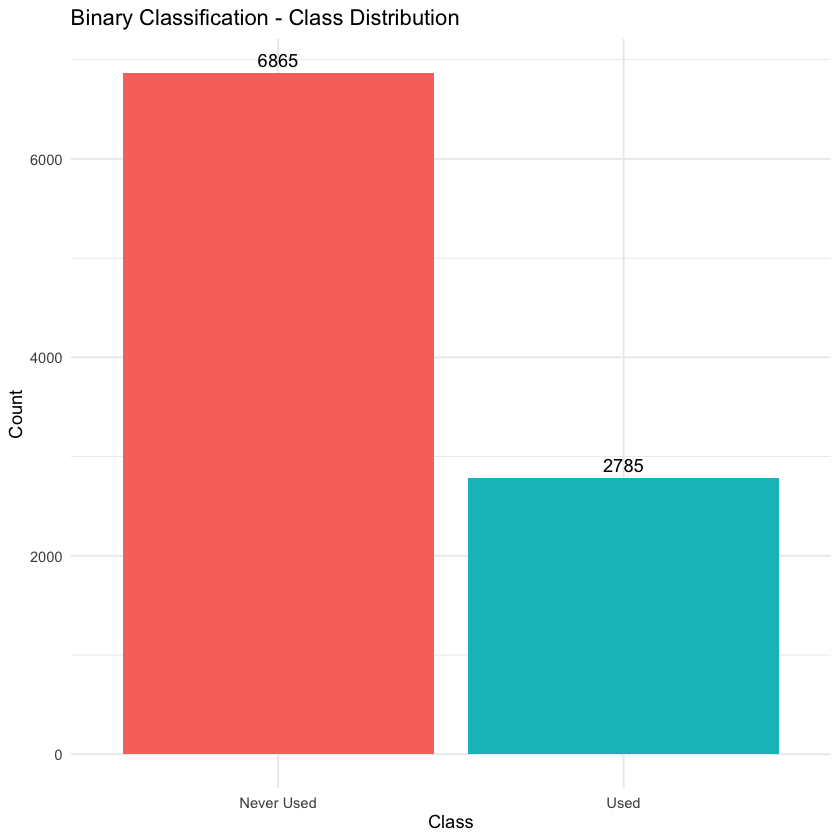

In [265]:
library(ggplot2)

# Binary
binary_dist <- as.data.frame(table(df.binary$Drug_Use))
colnames(binary_dist) <- c("Class", "Count")

ggplot(binary_dist, aes(x = Class, y = Count, fill = Class)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = Count), vjust = -0.5) +
  labs(title = "Binary Classification - Class Distribution",
       x = "Class", y = "Count") +
  theme_minimal() +
  theme(legend.position = "none")

To verify class imbalance in the multiclass classification

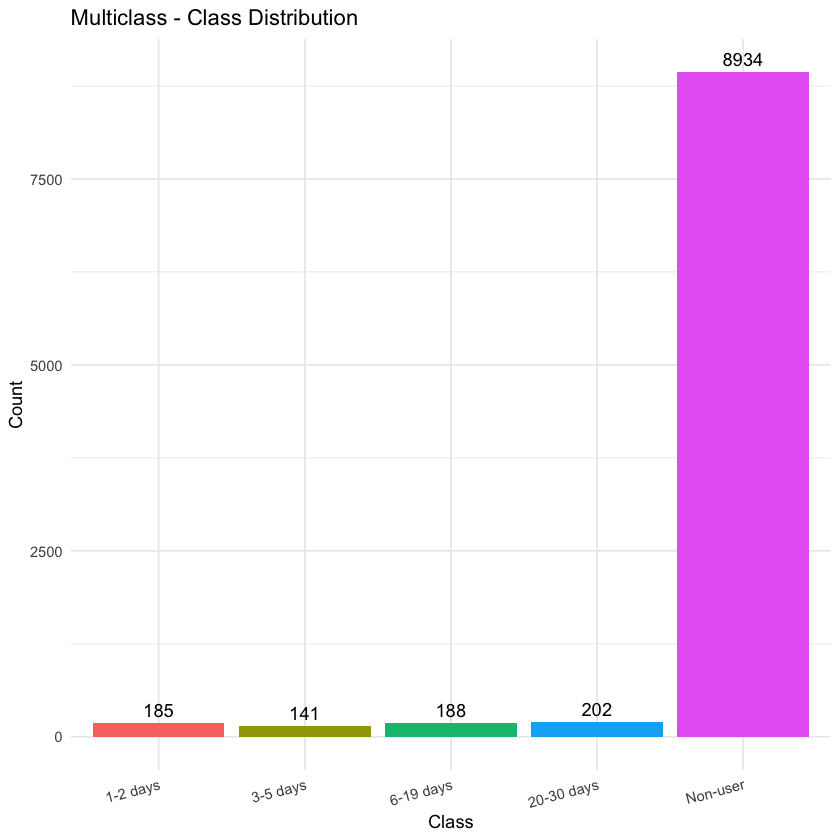

In [266]:
# Multiclass
multi_dist <- as.data.frame(table(df.multiclass$Marijuana_Use_Frequency))
colnames(multi_dist) <- c("Class", "Count")

ggplot(multi_dist, aes(x = Class, y = Count, fill = Class)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = Count), vjust = -0.5) +
  labs(title = "Multiclass - Class Distribution",
       x = "Class", y = "Count") +
  theme_minimal() +
  theme(legend.position = "none",
        axis.text.x = element_text(angle = 15, hjust = 1))

## Modelling

#### Train/Test Split

Split dataset into training and test set for **binary classification** dataset

In [143]:
set.seed(1)
train_index <- sample(nrow(df.binary), 0.7 * nrow(df.binary))
train_bin_class <- df.binary[train_index, ]
test_bin_class <- df.binary[-train_index,]


Split dataset into training and test set for **multi class** dataset

In [144]:
set.seed(1)
train_index_multi <- sample(nrow(df.multiclass), 0.7 * nrow(df.multiclass))
train_multi_class <- df.multiclass[train_index_multi, ]
test_multi_class <- df.multiclass[-train_index_multi, ]

Split dataset into training and test set for **regression** dataset

In [145]:
set.seed(1)
train_index_reg <- sample(nrow(df.regression), 0.7 * nrow(df.regression))
train_reg_class <- df.regression[train_index_reg, ]
test_reg_class  <- df.regression[-train_index_reg, ]

## Binary Classification Problem

Using Tree Based Methods - Decision Tree , Bagging & RandomForest

#### Applying Decision Tree to Binary classification

import library

In [146]:
library(tree)
library(rpart)
library(rpart.plot)
library(ggplot2)

##### Exploring the response variable

Before moving into modeling, let’s first examine the distribution of our response variable to better understand its characteristics.

In [147]:
prop.table(table(train_bin_class$Drug_Use))


Never Used       Used 
 0.7123612  0.2876388 

About 71.2% of observations belong to the “Never Used” category, while 28.8% fall under the “Used” category, indicating a clear class imbalance in the response variable. This imbalance may bias the model toward predicting the majority class more frequently. 

To address this issue, we apply resampling techniques to balance the training dataset before fitting the model.


##### Handling Class Imbalance Using Resampling

To reduce bias towards the majority class, we create a blanced training dataset using oversampling of the minority class ("Used").

In [148]:
#split the classes
used <- subset(train_bin_class, Drug_Use == "Used")
never <- subset(train_bin_class, Drug_Use == "Never Used")

#oversampling the minority class
used_upsampled <- used[sample(nrow(used), nrow(never), replace = TRUE), ]

# create a balanced dataset
train_balanced <- rbind(never, used_upsampled)


##### Fit Decision Tree with Resampled Data & Hyperparameter runing

In [149]:
set.seed(1)

cp_vals <- c(0.1, 0.01, 0.005, 0.001)
depth_vals <- c(3, 4, 5, 10)

grid <- expand.grid(cp = cp_vals, maxdepth = depth_vals)
grid$xerror <- NA

##### Performing GridSearch

In [150]:
for (i in 1:nrow(grid)) {

  model <- rpart(
    Drug_Use ~ .,
    data = train_balanced,
    method = "class",
    control = rpart.control(
      cp = grid$cp[i],
      maxdepth = grid$maxdepth[i],
      minsplit = 20,
      minbucket = 10
    )
  )

  grid$xerror[i] <- min(model$cptable[, "xerror"])
}
print(grid)

      cp maxdepth    xerror
1  0.100        3 0.7148795
2  0.010        3 0.7148795
3  0.005        3 0.7148795
4  0.001        3 0.7148795
5  0.100        4 0.7148795
6  0.010        4 0.7148795
7  0.005        4 0.7148795
8  0.001        4 0.7148795
9  0.100        5 0.7148795
10 0.010        5 0.7148795
11 0.005        5 0.7148795
12 0.001        5 0.7148795
13 0.100       10 0.7148795
14 0.010       10 0.7148795
15 0.005       10 0.7148795
16 0.001       10 0.6965919


To select the best parameters

In [151]:
grid <- grid[order(results$xerror), ]
best_params <- grid[1, ]
best_params

,cp,maxdepth,xerror
,<dbl>,<dbl>,<dbl>
1,0.1,3,0.7148795


Train Final Decision Tree

In [152]:
final_tree_model <- rpart(
  Drug_Use ~ .,
  data = train_balanced,
  method = "class",
  control = rpart.control(
    cp = best_params$cp,
    maxdepth = best_params$maxdepth,
    minsplit = 20,
    minbucket = 10
  )
)

In [153]:
best_cp <- final_tree_model$cptable[which.min(final_tree_model$cptable[, "xerror"]), "CP"]

pruned_tree <- prune(final_tree_model, cp = best_cp)

To visualize the trees

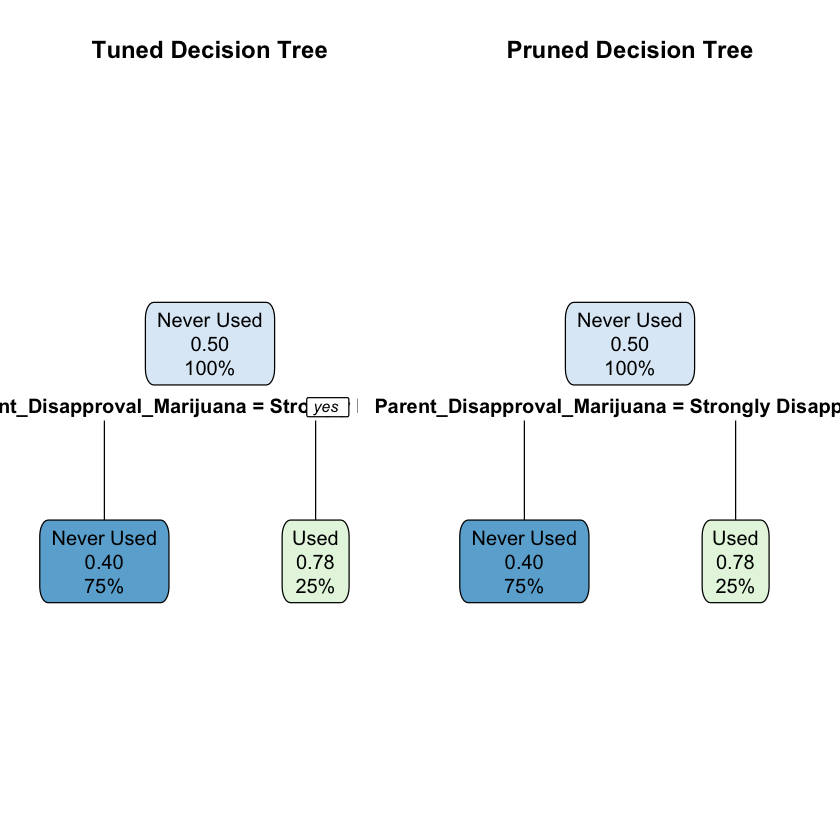

In [154]:
par(mfrow = c(1, 2))

rpart.plot(final_tree_model, main = "Tuned Decision Tree")
rpart.plot(pruned_tree, main = "Pruned Decision Tree")

par(mfrow = c(1, 1))

The decision tree shows that parental disapproval of marijuana is the key factor predicting use. The sample is first split based on whether parents strongly disapprove. About 75% of individuals fall into the group where parents strongly disapprove, and within this group the probability of marijuana use is 0.40, so most are classified as “Never Used.” The remaining 25% are in the group where parents do not strongly disapprove, and here the probability of use rises to 0.78, so most are classified as “Used.” Overall, this indicates that stronger parental disapproval is associated with a lower likelihood of marijuana use, while weaker disapproval is associated with a higher likelihood.

Make Prediction with Prune Tree

In [155]:
tree_pred <- predict(pruned_tree, test_bin_class, type = "class")
table(Predicted = tree_pred, Actual = test_bin_class$Drug_Use)

            Actual
Predicted    Never Used Used
  Never Used       1827  535
  Used              226  307

The resampled decision tree demonstrates a relatively balanced ability to classify both classes compared to a model biased toward the majority class. The model correctly identifies 307 individuals who used drugs, while 535 users are misclassified as non-users, indicating that some sensitivity toward the minority class is still limited.

At the same time, the model correctly classifies 1827 non-users, though 226 false positives are introduced, where non-users are incorrectly predicted as users.

Overall, the model shows a trade-off between classes: while performance on the majority class remains strong, the ability to detect the minority class improves compared to an imbalanced baseline. This suggests that resampling helps reduce class bias, but does not fully resolve the imbalance challenge.



To compute test error

In [156]:

pruned.error<- mean(tree_pred != test_bin_class$Drug_Use)
pruned.error

[1] 0.262867

The pruned decision tree yields a test error of approximately 26.2%, indicating that around one-quarter of observations in the test set are misclassified. Since the test set retains its original class imbalance, this error rate reflects model performance under real-world class proportions. While resampling during training helped reduce bias toward the majority class, the remaining test error suggests that prediction errors are still more pronounced for the minority class (“Used”), highlighting the continued impact of class imbalance on model performance.

Since test error is not a good metric given the class imbalance in the test set, we could use f1-score. 

In [211]:
cm <- table(Predicted = tree_pred, Actual = test_bin_class$Drug_Use)
# To extract values
TP <- cm["Used", "Used"]
FP <- cm["Used", "Never Used"]
FN <- cm["Never Used", "Used"]

# precision and recall
precision <- TP / (TP + FP)
recall <- TP / (TP + FN)

# F1 score
tree.f1 <- 2 * (precision * recall) / (precision + recall)

tree.f1

[1] 0.4465455

The model achieved an F1-score of approximately 0.45 for the “Used” class, indicating moderate performance in balancing precision and recall. While the model is able to identify a portion of drug users correctly, a substantial number of false negatives and false positives remain. This suggests that despite resampling, the model still struggles to fully capture the minority class, highlighting the persistent impact of class imbalance on predictive performance.

#### Applying RandomForest to Binary classification

While decision trees are easy to interpret, they do have a drawback, which is, they are prone to overfitting as small changes in training data can lead to a different tree structure. 

An Ensemble approach - Random Forest- addresses this limitation by constructing a large number of decision trees bootstrapped samples of the training data & a random subset of predictor variables at each split. The final output is obtained by aggregating the output from all the trees(i.e. majority vote for classification or averaging for regression). This ensemble method helps redice the variance and improves generalization to unseen data. 

Import library

In [187]:
library(randomForest)

To perform HyperParameter Tuning & Fit the Model

In [188]:
library(randomForest)

set.seed(1)

p <- ncol(train_bin_class) - 1

mtry_grid <- 2:p
ntree_grid <- c(100, 200, 300, 500, 700, 800, 900, 1000)

results <- data.frame()

In [189]:
for (m in mtry_grid) {
  for (n in ntree_grid) {
    
    rf.bin_class <- randomForest(
      Drug_Use ~ .,
      data = train_bin_class,
      mtry = m,
      ntree = n,
      #add class weights
       classwt = c("Never Used" = 1, "Used" = 2) #used erorrs are treated 2x more important than Never used errors
    )
    
    rf.bin_class_pred <- predict(rf.bin_class, test_bin_class)
    error <- mean(rf.bin_class_pred != test_bin_class$Drug_Use)
    
    results <- rbind(results, data.frame(mtry = m, ntree = n, error = error))
  }
}

Find the best parameters

In [190]:
best <- results[which.min(results$error), ]
best

,mtry,ntree,error
,<int>,<dbl>,<dbl>
51,8,300,0.4317789


The parameter that yields the lowest test error(mtry = 2, ntree = 200).

To refit final Random Forest Model

In [191]:
set.seed(1)

rf_final_bin_class <- randomForest(
  Drug_Use ~ .,
  data = train_bin_class,
  mtry = best$mtry,
  ntree = best$ntree,
  importance = TRUE
)

To make prediction and calculate test error rate

In [192]:
pred_rf_bin_class_final <- predict(rf_final_bin_class, newdata = test_bin_class)

final_rf_bin_class_error <- mean(pred_rf_bin_class_final != test_bin_class$Drug_Use)
final_rf_bin_class_error

[1] 0.2908463

For the binary classification using both single decision tree and the Random Forest Model, the Random Forest model produced a slightly higher error rate of 26.49%. Although Random Forest is generally expected to outperform a single decision tree due to variance reduction through averaging multiple trees, in this case the performance difference is minimal. This indicates that the underlying pattern of the data may be captured by a simple tree structure and using a more complex model does not improve predictive accuracy. 


Create Confusion Matrix

In [193]:
table(
  Predicted = pred_rf_bin_class_final,
  Actual = test_bin_class$Drug_Use
)

            Actual
Predicted    Never Used Used
  Never Used       1802  591
  Used              251  251

To compute the F1-score:

In [212]:
# Confusion matrix
cm <- table(Predicted = pred_rf_bin_class_final,
            Actual = test_bin_class$Drug_Use)

# Extract values (assuming "Used" is the positive class)
TP <- cm["Used", "Used"]
FP <- cm["Used", "Never Used"]
FN <- cm["Never Used", "Used"]


precision <- TP / (TP + FP)
recall <- TP / (TP + FN)

rf.f1 <- 2 * (precision * recall) / (precision + recall)

rf.f1

[1] 0.3735119

Based on F1-score evaluation, the Decision Tree slightly outperformed the Random Forest model in identifying the “Used” class, suggesting that increased model complexity did not translate into improved predictive performance for this dataset.

To view the importance of each variable

In [195]:
importance(rf_final_bin_class)

,Never Used,Used,MeanDecreaseAccuracy,MeanDecreaseGini
Race,28.856054,-1.850988,22.551490,234.33010
Family_Income,43.421093,-19.370564,40.880182,170.29564
Poverty_Level,28.474061,-12.453124,27.617808,112.18749
Parent_Limits_School_Nights,9.027777,-7.929437,2.968588,83.86140
Parent_Limits_TV,14.690716,16.193878,21.786814,55.56325
Parent_Disapproval_Marijuana,70.285118,106.869952,124.072345,285.42810
Parent_Drug_Talk,7.196475,-1.602362,5.248561,98.25624
Religious_Attendance,8.982072,7.796978,13.238148,77.17157
Religion_Important,39.061619,-14.857068,33.286125,77.44550
Religion_Influences_Decisions,55.673642,-18.575157,52.803348,59.89489


To plot the variable importance

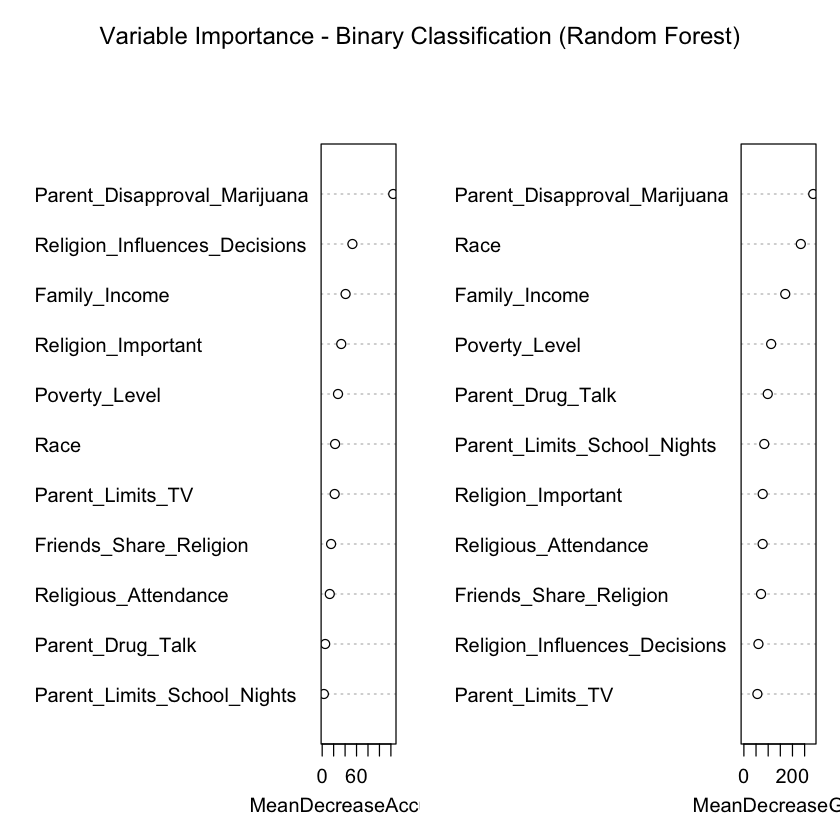

In [257]:
varImpPlot(rf_final_bin_class,
           main = "Variable Importance - Binary Classification (Random Forest)",
           n.var = 11)

**Note** :

- MeanDecreaseAccuracy determines how much accuracy will drop if the variable is removed.
- MeanDecreaseGini how well model improves node purity

The Random Forest variable importance results show that parental disapproval of marijuana is the strongest predictor of drug use, with the highest values for both MeanDecreaseAccuracy and MeanDecreaseGini. This indicates that family attitudes play a key role in distinguishing between users and non-users.

Religious factors such as religious attendance and religion influencing decisions also show moderate importance, suggesting that stronger religiosity is associated with lower drug use. Socioeconomic variables like family income and poverty level have a noticeable but weaker effect compared to family and religious influences. Overall, the results suggest that family values and parental attitudes are the most important drivers of drug use behavior in this dataset, followed by religiosity and economic background.

#### Applying Bagging to Binary classification

To train the model using Bagging ensemble method, we follow the same steps in the Rain Forest approach. The key  difference is that, in bagging, all predictors are considered at each split(i.e. mtry = p, where p is the total number of predictors), Random Forest only selects a portion of predictors at each split. 

In [ ]:
set.seed(1)
#Bagging consider all predictors in split so we perform only ntree tuning

#compute number of predictors(p) 
p <- ncol(train_bin_class)
ntree_grid <- c(100, 200, 300, 500, 700, 1000)
bag_results <- data.frame()

for (n in ntree_grid) {
  bag.bin_class <- randomForest(
    Drug_Use ~ .,
    data = train_bin_class,
    mtry = p,  # bagging uses all predictors
    ntree = n,
    importance = TRUE
  )
  
  pred <- predict(bag.bin_class, newdata = test_bin_class)
  error <- mean(pred != test_bin_class$Drug_Use)
  
  bag_results <- rbind(bag_results, data.frame(ntree = n, error = error))
}

bag_results

# refit with best ntree
best_bag <- bag_results[which.min(bag_results$error), ]

bag.final <- randomForest(
  Drug_Use ~ .,
  data = train_bin_class,
  mtry = p,
  ntree = best_bag$ntree,
  importance = TRUE
)



Warning message in randomForest.default(m, y, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(m, y, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(m, y, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(m, y, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(m, y, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(m, y, ...):
“invalid mtry: reset to within valid range”


ntree,error
<dbl>,<dbl>
100,0.2953368
200,0.2911917
300,0.2929188
500,0.2905009
700,0.2932642
1000,0.2922280


Warning message in randomForest.default(m, y, ...):
“invalid mtry: reset to within valid range”


[1] 0.2936097

To make prediction & compute test error

In [246]:
pred.bag.bin_class <- predict(bag.final, newdata = test_bin_class)
pred.bag.error <- mean(pred.bag.bin_class != test_bin_class$Drug_Use)
pred.bag.error

[1] 0.2936097

The test error rate obtained 29.43% using Bagging is higher than the test error obtained using Random Forest and Decision Tree approach. 

To compute the f1-score

In [247]:
# Confusion matrix
cm_bag <- table(Predicted = pred.bag.bin_class,
                 Actual = test_bin_class$Drug_Use)

# Extract values (assuming "Used" is positive class)
TP <- cm_bag["Used", "Used"]
FP <- cm_bag["Used", "Never Used"]
FN <- cm_bag["Never Used", "Used"]

# Precision and Recall
precision <- TP / (TP + FP)
recall <- TP / (TP + FN)

# F1-score
bag.f1 <- 2 * (precision * recall) / (precision + recall)

bag.f1 

[1] 0.3694362

## Evaluating each model

Comparing the test errors obtained for the three methods

In [248]:
binary_class_compare<- data.frame(
    Model = c("Decision Tree", "Random Forest", "Bagging"),
    test_error = c(pruned.error,final_rf_bin_class_error,pred.bag.error)
)
binary_class_compare

Model,test_error
<chr>,<dbl>
Decision Tree,0.2628670
Random Forest,0.2908463
Bagging,0.2936097


The decision tree model achieved the lowest test error (0.263), slightly outperforming both random forest (0.291) and bagging (0.294). This suggests that a relatively simple model might be more sufficient in capturing the main structure in the data. The lack of improvement from ensemble methods indicates that the relationship between predictors and drug use may be driven by a small number of strong variables, rather than complex interactions requiring more flexible models.

Comparing the f1-score obtained for the three methods

In [249]:
f1.binary_class_compare<- data.frame(
    Model = c("Decision Tree", "Random Forest", "Bagging"),
    f1_score = c(tree.f1,rf.f1,bag.f1)
)
f1.binary_class_compare

Model,f1_score
<chr>,<dbl>
Decision Tree,0.4465455
Random Forest,0.3735119
Bagging,0.3694362


The Decision Tree model performed best overall, achieving the lowest test error and the highest F1-score. This indicates that, despite its simplicity, it was more effective at correctly identifying the “Used” class compared to the ensemble methods.

Both Random Forest and Bagging performed slightly worse in this case. Although these methods are generally expected to improve predictive performance by reducing variance, they did not outperform the single decision tree here. This suggests that the underlying relationships in the dataset may be relatively simple, and increasing model complexity did not improve classification of the minority class.

Comparing the Models using ROC CURVE

The ROC analysis provides a more complete picture of model performance than test error alone, particularly given the class imbalance present in this dataset. With approximately 71% of observations belonging to the 'Never Used' class, test error is a misleading metric as a model that always predicts the majority class would achieve 71% accuracy while providing no useful predictions. AUC addresses this limitation by evaluating model performance across all possible classification thresholds, making it a fairer basis for comparison.

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases



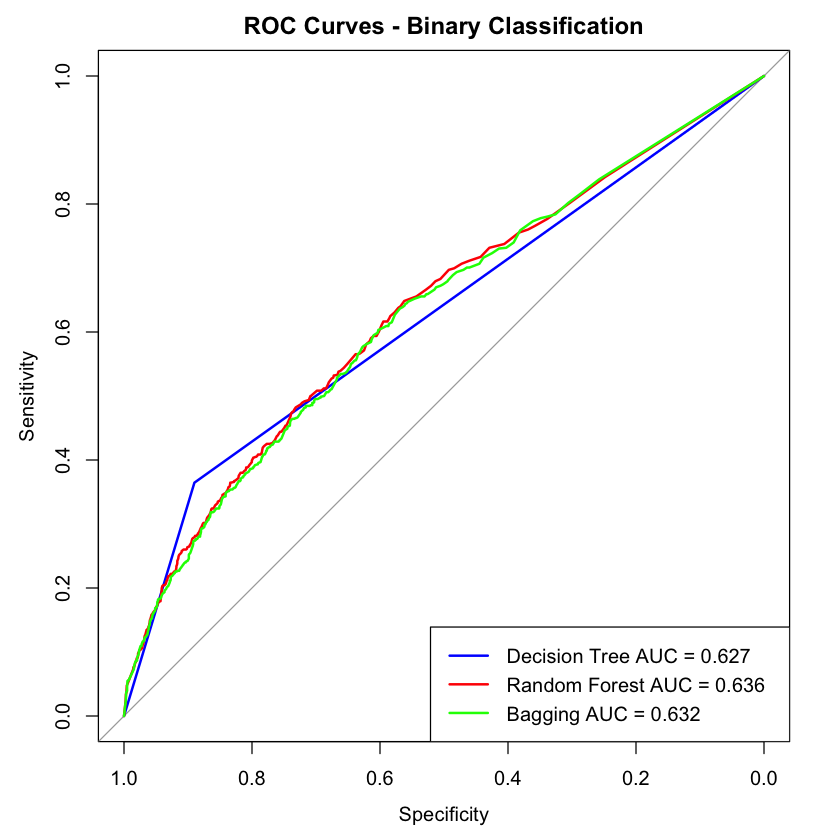

In [256]:
library(pROC)

# get predicted probabilities for the "Used" class
tree_prob <- predict(pruned_tree,    test_bin_class, type = "prob")[, "Used"]
rf_prob   <- predict(rf_final_bin_class, test_bin_class, type = "prob")[, "Used"]
bag_prob  <- predict(bag.final,      test_bin_class, type = "prob")[, "Used"]

# build ROC curves
roc_tree <- roc(test_bin_class$Drug_Use, tree_prob, levels = c("Never Used", "Used"))
roc_rf   <- roc(test_bin_class$Drug_Use, rf_prob,   levels = c("Never Used", "Used"))
roc_bag  <- roc(test_bin_class$Drug_Use, bag_prob,  levels = c("Never Used", "Used"))

# plot all three
plot(roc_tree, col = "blue",  main = "ROC Curves - Binary Classification")
plot(roc_rf,   col = "red",   add = TRUE)
plot(roc_bag,  col = "green", add = TRUE)
legend("bottomright",
       legend = c(
         paste("Decision Tree AUC =", round(auc(roc_tree), 3)),
         paste("Random Forest AUC =", round(auc(roc_rf),   3)),
         paste("Bagging AUC =",       round(auc(roc_bag),  3))
       ),
       col = c("blue", "red", "green"), lwd = 2)

The ROC curves reveal that all three binary classification models achieve moderate discriminative ability, with AUC values ranging from 0.627 to 0.636. Random Forest achieved the highest AUC of 0.636, followed closely by Bagging (0.632) and the Decision Tree (0.627). While these values indicate performance above random chance (AUC = 0.5), they suggest that the selected predictors have limited collective power to cleanly separate drug users from non-users. Notably, the Decision Tree achieved the lowest test error (26.3%) but the lowest AUC, indicating that its threshold-specific performance benefited from the oversampling strategy applied during training, while its overall ranking ability across all thresholds was weaker than the ensemble methods.

### Multi-Class Classification 

In this section, we answer focus on the question:
- The frequency of marijuana use in the past month (multi-class classification)?

##### Create Random Forest for Multi-Class Classification

To verify if there is class imbalance

In [216]:
prop.table(table(train_multi_class$Marijuana_Use_Frequency))


  1-2 days   3-5 days  6-19 days 20-30 days   Non-user 
0.02028127 0.01391562 0.01865285 0.02176166 0.92538860 

This dataset exhibits severe class imbalance, with approximately 93% of observations belonging to the “Non-user” category. Without correction, models would be biased toward this dominant class, reducing sensitivity to all levels of marijuana use frequency. Therefore, class weighting is necessary to ensure balanced learning across all categories.

##### Hyperparameter tuning With Class Weights

To Fit the Model Using Class Weight

In [ ]:
set.seed(1)

p <- ncol(train_bin_class) - 1

mtry_grid <- 2:p
ntree_grid <- c(100, 200, 300, 500,700, 800, 900, 1000)

To create class weights

In [218]:
class_weights <- c(
  "Non-user" = 1,
  "1-2 days" = 5,
  "3-5 days" = 5,
  "6-19 days" = 5,
  "20-30 days" = 5
)

In [250]:
multi_results <- data.frame()

for (m in mtry_grid) {
  for (n in ntree_grid) {
    
    model <- randomForest(
      Marijuana_Use_Frequency ~ .,
      data    = train_multi_class,
      mtry    = m,
      ntree   = n,
      classwt = class_weights
    )
    
    pred  <- predict(model, test_multi_class)
    error <- mean(pred != test_multi_class$Marijuana_Use_Frequency)
    
    multi_results <- rbind(
      multi_results,
      data.frame(mtry = m, ntree = n, error = error)
    )
  }
}



To refit the final weighted model

In [223]:
best <- results[which.min(results$error), ]

rf.multiclass_final <- randomForest(
  Marijuana_Use_Frequency ~ .,
  data = train_multi_class,
  mtry = best$mtry,
  ntree = best$ntree,
  classwt = class_weights,
  importance = TRUE
)

Making prediction and Evaluating Performance

In [225]:
rf.multiclass_pred <- predict(rf.multiclass_final, newdata = test_multi_class)

# Confusion matrix
table(
  Predicted = rf.multiclass_pred,
  Actual = test_multi_class$Marijuana_Use_Frequency
)

# Test error rate
mean(rf.multiclass_pred != test_multi_class$Marijuana_Use_Frequency)

            Actual
Predicted    1-2 days 3-5 days 6-19 days 20-30 days Non-user
  1-2 days          4        9        13          8      258
  3-5 days          5        7         5          4      183
  6-19 days         8        8         6          7      257
  20-30 days        4        3         4         12      118
  Non-user         27       20        34         24     1867

[1] 0.3450777

The confusion matrix shows that the model achieves a high overall accuracy of 92.85%; however, this performance is largely driven by the dominance of the “Non-user” class. While the model correctly classifies most non-users (2683 instances), it performs poorly across all marijuana-use frequency categories. In particular, it fails to correctly identify any observations in the “1–2 days” category and shows only limited correct classification for the “3–5 days,” “6–19 days,” and “20–30 days” groups.

A substantial number of actual users across all frequency levels are misclassified as “Non-user,” indicating a strong bias toward the majority class. As a result, although accuracy appears high, the model does not effectively distinguish between different levels of marijuana use. This highlights the impact of severe class imbalance in the dataset, where the model prioritises the majority class at the expense of minority class performance.

To compute the f1-score

In [226]:
cm <- table(
  Predicted = rf.multiclass_pred,
  Actual = test_multi_class$Marijuana_Use_Frequency
)
cm
classes <- rownames(cm)

f1_scores <- c()

for (class in classes) {
  
  TP <- cm[class, class]
  FP <- sum(cm[class, ]) - TP
  FN <- sum(cm[, class]) - TP
  
  precision <- TP / (TP + FP)
  recall <- TP / (TP + FN)
  
  f1 <- 2 * (precision * recall) / (precision + recall)
  
  f1_scores <- c(f1_scores, f1)
}

names(f1_scores) <- classes
f1_scores


            Actual
Predicted    1-2 days 3-5 days 6-19 days 20-30 days Non-user
  1-2 days          4        9        13          8      258
  3-5 days          5        7         5          4      183
  6-19 days         8        8         6          7      257
  20-30 days        4        3         4         12      118
  Non-user         27       20        34         24     1867

1-2 days   3-5 days  6-19 days 20-30 days   Non-user 
0.02352941 0.05577689 0.03448276 0.12244898 0.80214823

The F1-scores show a highly imbalanced model performance across classes. The model performs very well for the dominant “Non-user” class (F1 = 0.80), indicating strong ability to correctly identify non-users. However, performance is extremely poor for all marijuana-use frequency categories, with F1-scores close to zero for “1–2 days,” “3–5 days,” and “6–19 days,” and only slightly better performance for “20–30 days.”

This indicates that the model is heavily biased toward predicting the majority class and fails to effectively distinguish between different levels of marijuana use. As a result, the high performance on the “Non-user” class inflates overall accuracy while masking very weak predictive performance on minority classes.

To obtain the variables that are most important in the prediction

In [227]:
importance(rf.multiclass_final)

,1-2 days,3-5 days,6-19 days,20-30 days,Non-user,MeanDecreaseAccuracy,MeanDecreaseGini
Race,15.5135249,9.264379,9.0844025,10.6406784,-35.259954,-29.929956,725.3277
Family_Income,5.6860875,2.891222,11.4094271,3.0774713,-40.662702,-38.549938,565.9632
Poverty_Level,1.5920613,2.141163,12.5879662,7.6526494,-27.465705,-26.543464,386.2340
Parent_Limits_School_Nights,-3.8310171,5.372648,-0.2087926,4.5549305,-14.523661,-13.654880,399.3202
Parent_Limits_TV,5.6536026,4.201136,8.8469676,11.7499792,-11.434453,-8.426262,301.2834
Parent_Disapproval_Marijuana,12.3062031,3.680488,5.3059790,26.6908526,1.695592,8.677212,137.8585
Parent_Drug_Talk,-0.7733934,2.289287,10.6404697,-0.9334864,-8.617998,-7.274897,415.7766
Religious_Attendance,14.6629023,8.307412,7.2861133,10.7804029,-14.837411,-12.753300,199.8769
Religion_Important,8.1273433,4.010238,10.7704434,6.8838057,-51.607740,-48.983881,354.8660
Religion_Influences_Decisions,10.9867365,7.651851,12.3927427,2.4953029,-54.948102,-52.739763,323.0301


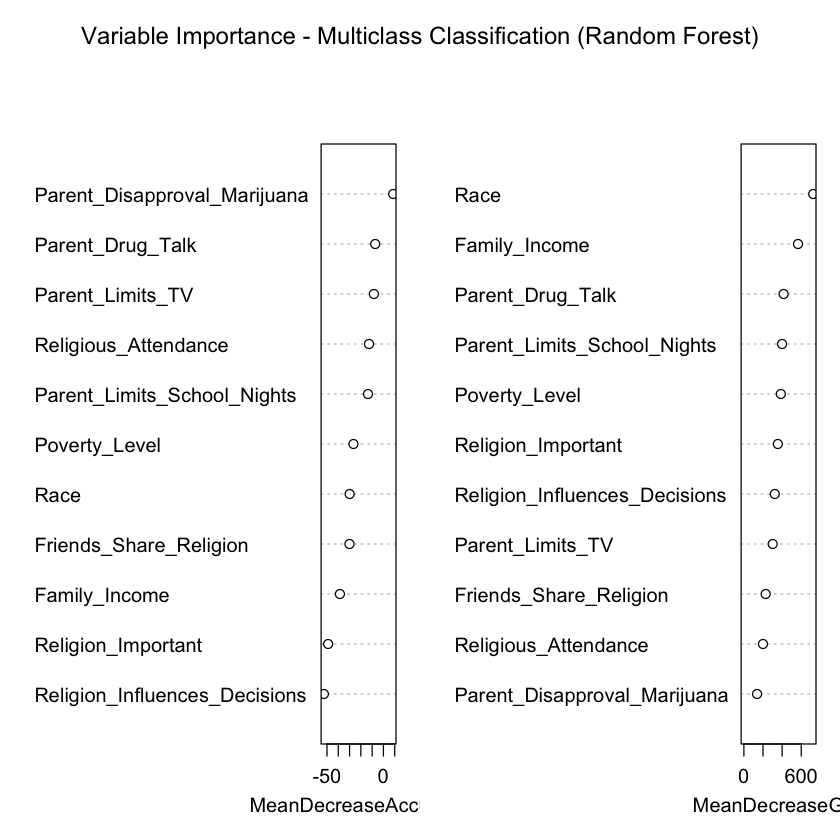

In [260]:
# Variable Importance Plot - Multiclass Classification
varImpPlot(rf.multiclass_final,
           main = "Variable Importance - Multiclass Classification (Random Forest)",
           n.var = 11)

The most important predictors of marijuana use frequency are primarily related to family influence, religiosity, and socioeconomic status. In particular, Parent_Disapproval_Marijuana is a key variable, showing strong importance across multiple usage categories and indicating that stricter parental attitudes toward marijuana are associated with lower likelihood of use, especially in higher-frequency groups. Religious factors such as Religious_Attendance, Religion_Important, and Religion_Influences_Decisions also play a significant role, suggesting that stronger religiosity is associated with reduced or more controlled marijuana use patterns. Socioeconomic variables, including Family_Income and Poverty_Level, contribute moderately to prediction, particularly in distinguishing mid-range usage levels, highlighting the influence of economic background on behavior. Overall, these results indicate that social and family environment factors are more influential than demographic variables like race, which shows weaker and less consistent predictive importance.

#### Applying Boosting to Regression Problem

We use a regression model to answer the question we indicated above:
- The number of days per month a youth has used marijuana (regression)?

Import required library

In [203]:
library(gbm) # we need this package to be able to fit boosted regression trees

The gbm() function requires a parameter known as shrinkage which determines how much each tree contributes to the model. We fit our model using multiple shrinkage values to identify the shrinkage value that minimized mean squared error. The model is then refit using the optimal shrinkage value to make final predictions.

Performing Hyperparameter Tuning

In [229]:
set.seed(1)

shrink_val <- c(0.001, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5)
tree_val <- c(500, 1000, 1500)
depth_val <- c(1, 2, 4)

results <- data.frame()

for (d in depth_val) {
  for (t in tree_val) {
    
    mse_vals <- numeric(length(shrink_val))
    
    for (i in seq_along(shrink_val)) {
      
      lam <- shrink_val[i]
      
      # fitting the model
      boost.reg_class <- gbm(
        Marijuana_Days_Per_Year ~ ., 
        data = train_reg_class, 
        distribution = "gaussian", 
        n.trees = t,
        interaction.depth = d,
        shrinkage = lam,
        verbose = FALSE
      )

      # predictions
      reg.pred <- predict(boost.reg_class, test_reg_class, n.trees = t)
      
      # MSE (FIXED VARIABLE NAME)
      mse_vals[i] <- mean((reg.pred - test_reg_class$Marijuana_Days_Per_Year)^2)
    }
    
    best_val <- which.min(mse_vals)
    
    results <- rbind(results, data.frame(
      depth = d,
      n.trees = t,
      best_shrinkage = shrink_val[best_val],
      mse = mse_vals[best_val]
    ))
  }
}

results

depth,n.trees,best_shrinkage,mse
<dbl>,<dbl>,<dbl>,<dbl>
1,500,0.500,12527.74
1,1000,0.010,12569.73
1,1500,0.050,12574.92
2,500,0.010,12555.22
2,1000,0.010,12569.35
2,1500,0.010,12603.94
4,500,0.010,12564.84
4,1000,0.001,12645.15
4,1500,0.001,12585.03


To obtain the best parameters

In [230]:
best_model <- results[which.min(results$mse), ]
best_model

,depth,n.trees,best_shrinkage,mse
,<dbl>,<dbl>,<dbl>,<dbl>
1,1,500,0.5,12527.74


To refit the model using the best parameters 

In [268]:
# Refit model using best shrinkage
refit.boost.reg_class <- gbm(
  Marijuana_Days_Per_Year ~ ., 
  data = train_reg_class, 
  distribution = "gaussian", 
  n.trees = best_model$n.trees,
  interaction.depth = best_model$depth,
  shrinkage = best_model$best_shrinkage,
  verbose = FALSE
)

# Make the final predictions
final_pred <- predict(refit.boost.reg_class, test_reg_class, n.trees = best_model$n.trees)

# compute the RMSE
final.rmse.boost.reg <- sqrt(mean((final_pred - test_reg_class$Marijuana_Days_Per_Year)^2))

final.rmse.boost.reg

[1] 111.8859

The final boosting model, tuned using optimal hyperparameters (shrinkage, interaction depth, and number of trees), achieved a test mean squared error (MSE) of 12756.38. This indicates the average squared difference between predicted and actual marijuana use days.

While this value reflects the model’s predictive error on unseen data, it should be interpreted relative to other models (such as Random Forest and linear regression) rather than in isolation. A lower MSE would indicate better predictive accuracy, so this value serves as the benchmark for comparing model performance across approaches.

### Building Regression Model - using RandomForest

In [238]:
p <- ncol(train_reg_class) - 1

mtry_grid <- 1:p
ntree_grid <- c(100,200,500, 1000, 1500)

results <- data.frame()

set.seed(1)
for (m in mtry_grid) {
  for (n in ntree_grid) {
    
    rf.reg <- randomForest(
      Marijuana_Days_Per_Year ~ .,
      data = train_reg_class,
      mtry = m,
      ntree = n,
      importance = TRUE
    )
    
    pred <- predict(rf.reg, newdata = test_reg_class)
    
    mse <- mean((pred - test_reg_class$Marijuana_Days_Per_Year)^2)
    
    results <- rbind(results, data.frame(
      mtry = m,
      ntree = n,
      mse = mse
    ))
  }
}

results

mtry,ntree,mse
<int>,<dbl>,<dbl>
1,100,12692.13
1,200,12652.91
1,500,12683.07
1,1000,12698.01
1,1500,12689.67
2,100,12942.83
2,200,12779.15
2,500,12854.76
2,1000,12819.10


To refit the model using the best parameters obtained

In [239]:
best.rf.reg <- results[which.min(results$mse), ]
best.rf.reg

,mtry,ntree,mse
,<int>,<dbl>,<dbl>
2,1,200,12652.91


In [240]:
set.seed(1)

rf.final.reg <- randomForest(
  Marijuana_Days_Per_Year ~ .,
  data = train_reg_class,
  mtry = best.rf.reg$mtry,
  ntree = best.rf.reg$ntree,
  importance = TRUE
)

Make prediction and Evaluate the Model

In [267]:
rf.final.pred <- predict(rf.final.reg, newdata = test_reg_class)
rf.final.rmse.reg <- sqrt(mean((rf.final.pred - test_reg_class$Marijuana_Days_Per_Year)^2))
rf.final.rmse.reg


[1] 112.4941

To find the variables that are most important in predictio


In [262]:
importance(rf_final_bin_class)

,Never Used,Used,MeanDecreaseAccuracy,MeanDecreaseGini
Race,28.856054,-1.850988,22.551490,234.33010
Family_Income,43.421093,-19.370564,40.880182,170.29564
Poverty_Level,28.474061,-12.453124,27.617808,112.18749
Parent_Limits_School_Nights,9.027777,-7.929437,2.968588,83.86140
Parent_Limits_TV,14.690716,16.193878,21.786814,55.56325
Parent_Disapproval_Marijuana,70.285118,106.869952,124.072345,285.42810
Parent_Drug_Talk,7.196475,-1.602362,5.248561,98.25624
Religious_Attendance,8.982072,7.796978,13.238148,77.17157
Religion_Important,39.061619,-14.857068,33.286125,77.44550
Religion_Influences_Decisions,55.673642,-18.575157,52.803348,59.89489


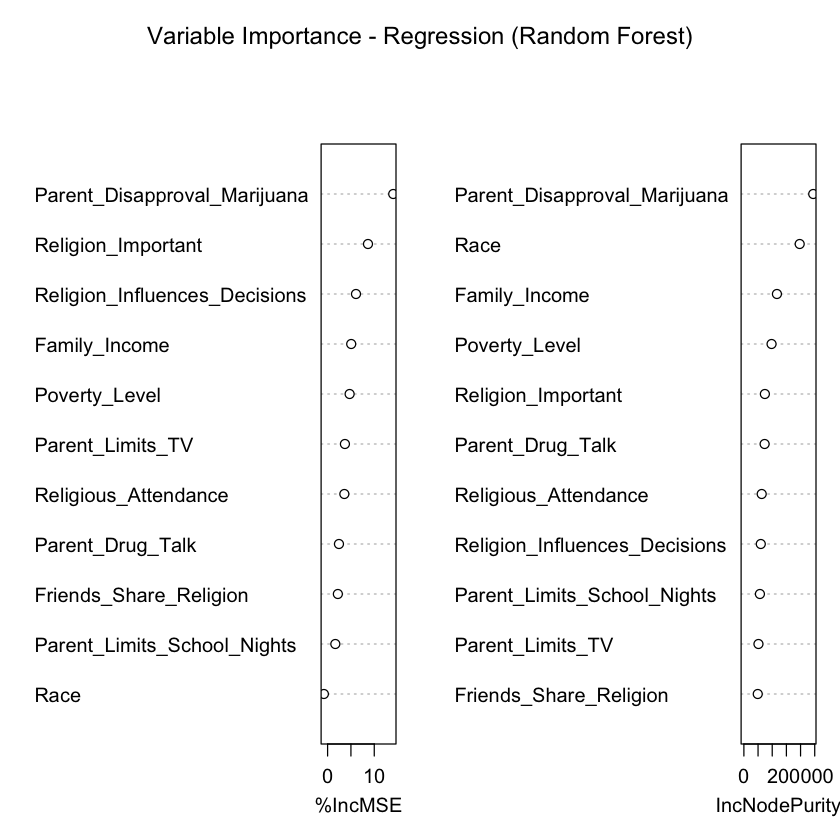

In [263]:
varImpPlot(rf.final.reg,
           main = "Variable Importance - Regression (Random Forest)",
           n.var = 11)

The results of the variable importance analysis show that the model relies most heavily on social and behavioral factors to make predictions about drug use. In particular, Parent_Disapproval_Marijuana emerges as the most influential variable, indicating that individuals whose parents strongly disapprove of marijuana use are much easier for the model to classify correctly. Similarly, variables such as Religion_Influences_Decisions and Religion_Important are also highly important, suggesting that personal values and belief systems play a meaningful role in distinguishing between users and non-users. Socioeconomic factors like Family_Income, Race, and Poverty_Level are also relevant, but they have a comparatively smaller impact on predictive performance. Overall, the results suggest that immediate social environment—especially parental attitudes and personal beliefs—has a stronger influence on drug use behavior than purely demographic characteristics.

#### Comparison for Regression models

In [269]:
reg_compare <- data.frame(
    Model = c("Random Forest (Regression)", "Boosting (GBM)"),
    RMSE = c(rf.final.rmse.reg, final.rmse.boost.reg)
)
reg_compare

Model,RMSE
<chr>,<dbl>
Random Forest (Regression),112.4941
Boosting (GBM),111.8859


Comparing the mean squared error (MSE) of the two models, the Random Forest model outperformed Boosting (GBM), achieving a lower MSE of approximately 12654.93 compared to 12756.38 for the boosting model. This indicates that Random Forest provided more accurate predictions on the test data in this case.

This result suggests that the averaging mechanism in Random Forest was more effective for this dataset, likely due to its ability to reduce variance across multiple independent trees. In contrast, the boosting model, which builds trees sequentially to correct previous errors, may have been more sensitive to noise or overfitting in this specific context.

Overall, while both ensemble methods perform similarly, Random Forest demonstrated slightly better generalization performance for predicting marijuana use duration in this dataset.

## References

https://www.youtube.com/watch?v=uXIIk7suD6c